# WF02 — FIRMS Detection Reliability

## 1. Objective

Investigate the reliability of NASA FIRMS active-fire observations for a
small, documented set of historical fire events.

## 2. Research questions

1. Are FIRMS observations present during the selected event's time window?
2. How close are the observations to the documented event location?
3. How much time separates the event reference time and the first
   available FIRMS observation?
4. Which cases require further investigation because observations are
   absent, delayed, or geographically distant?

## 3. Data sources

- FIRMS: satellite-derived active-fire observations.
- Independent event references: documented fire events with a source,
  date or date range, and approximate location.

## 4. Important definitions

- FIRMS detection: a satellite-observed thermal anomaly.
- Reference event: an event documented independently of the FIRMS
  detections being evaluated.
- Potential missed detection: no matching FIRMS observation was found
  within the defined search window. This does not prove the satellite
  failed to observe the event.
- Potential false alarm: a FIRMS observation that cannot be matched to
  the selected reference events. This does not prove the observation
  was false, because the reference-event list may be incomplete.

## 5. Method

1. Load historical FIRMS observations.
2. Validate timestamps, coordinates, and relevant attributes.
3. Create a documented event-reference table.
4. Match observations to events using a defined time window and
   geographic distance.
5. Inspect unmatched and matched cases.
6. Record limitations and results.

## 6. Scientific safeguards

- Do not use FIRMS observations themselves as independent ground truth.
- Do not call every thermal anomaly a wildfire.
- Do not report accuracy, precision, recall, or false-alarm rate without
  suitable reference labels and a clearly defined evaluation sample.
- Record the dataset, date range, matching rules, and limitations.
- Keep all conclusions proportional to the evidence.

## 7. Current status

This notebook establishes the historical-event reliability workflow.
Results will be reported only after the input data and event references
have been checked.

In [1]:
# ============================================================
# WF02 — CELL 2: ENVIRONMENT SETUP
# Purpose:
#   1. Install required Python libraries.
#   2. Import libraries.
#   3. Create input and output folders.
# ============================================================

%pip -q install pandas numpy matplotlib requests

import os
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from pathlib import Path

# Main experiment directory in Google Colab
BASE_DIR = Path("/content/wildfire_monitoring")

# Folder for historical FIRMS data and reference files
DATA_DIR = BASE_DIR / "data"

# Folder for experiment outputs
RESULTS_DIR = BASE_DIR / "results"

# Folder for independently documented fire-event references
EVENTS_DIR = DATA_DIR / "event_references"

# Create folders if they do not already exist
for folder in [DATA_DIR, RESULTS_DIR, EVENTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("WF02 environment setup completed.")
print("Base directory:", BASE_DIR)
print("Data directory:", DATA_DIR)
print("Results directory:", RESULTS_DIR)
print("Event references directory:", EVENTS_DIR)

WF02 environment setup completed.
Base directory: /content/wildfire_monitoring
Data directory: /content/wildfire_monitoring/data
Results directory: /content/wildfire_monitoring/results
Event references directory: /content/wildfire_monitoring/data/event_references


In [2]:
# ============================================================
# WF02 — CELL 3: CHECK THE WF01 SNAPSHOT
# Purpose:
#   1. Locate the previously downloaded FIRMS CSV.
#   2. Inspect its date coverage.
#   3. Prevent accidentally treating a recent snapshot as
#      a historical evaluation dataset.
# ============================================================

WF01_CSV_PATH = DATA_DIR / "MODIS_C6_1_Global_24h.csv"

if not WF01_CSV_PATH.exists():
    print("WF01 CSV was not found at the expected path:")
    print(WF01_CSV_PATH)
    print()
    print("If WF01 ran in another Colab runtime, its files may not")
    print("be available here. Upload the file or download it again.")
else:
    wf01_df = pd.read_csv(WF01_CSV_PATH)

    print("WF01 file found.")
    print("Rows:", len(wf01_df))
    print("Columns:", list(wf01_df.columns))

    if "acq_date" in wf01_df.columns:
        dates = pd.to_datetime(
            wf01_df["acq_date"],
            errors="coerce"
        ).dropna()

        if not dates.empty:
            print("Earliest acquisition date:", dates.min().date())
            print("Latest acquisition date:", dates.max().date())
        else:
            print("No valid acquisition dates were parsed.")
    else:
        print("The expected 'acq_date' column is missing.")

    print("\nImportant:")
    print("This recent snapshot is not sufficient for historical")
    print("event-reliability evaluation.")

WF01 CSV was not found at the expected path:
/content/wildfire_monitoring/data/MODIS_C6_1_Global_24h.csv

If WF01 ran in another Colab runtime, its files may not
be available here. Upload the file or download it again.


In [3]:
# ============================================================
# WF02 — CELL 4: CREATE EVENT REFERENCE TEMPLATE
# Purpose:
#   Create a structured table for independently documented
#   historical fire events.
#
# Important:
#   Do not fill this with guessed coordinates, dates, or labels.
#   Every event must have a verifiable reference source.
# ============================================================

EVENTS_CSV_PATH = EVENTS_DIR / "historical_fire_events.csv"

# Define the fields needed to document each event.
event_columns = [
    "event_id",
    "event_name",
    "country_or_region",
    "event_start_date",
    "event_end_date",
    "latitude",
    "longitude",
    "reference_source_name",
    "reference_source_url",
    "reference_notes",
    "verification_status"
]

# Create a blank template only if one does not already exist.
if not EVENTS_CSV_PATH.exists():
    empty_events_df = pd.DataFrame(columns=event_columns)
    empty_events_df.to_csv(EVENTS_CSV_PATH, index=False)
    print("Created a blank event-reference template.")
else:
    print("An event-reference template already exists.")

# Load and inspect the template.
events_df = pd.read_csv(EVENTS_CSV_PATH)

print("\nEvent-reference file:")
print(EVENTS_CSV_PATH)

print("\nColumns:")
print(events_df.columns.tolist())

print("\nCurrent number of documented events:", len(events_df))

display(events_df.head())

Created a blank event-reference template.

Event-reference file:
/content/wildfire_monitoring/data/event_references/historical_fire_events.csv

Columns:
['event_id', 'event_name', 'country_or_region', 'event_start_date', 'event_end_date', 'latitude', 'longitude', 'reference_source_name', 'reference_source_url', 'reference_notes', 'verification_status']

Current number of documented events: 0


,event_id,event_name,country_or_region,event_start_date,event_end_date,latitude,longitude,reference_source_name,reference_source_url,reference_notes,verification_status


In [4]:
# ============================================================
# WF02 — CELL 5: VALIDATE EVENT REFERENCES
# Purpose:
#   Check that event records have the minimum fields needed
#   for later spatial and temporal matching.
# ============================================================

events_df = pd.read_csv(EVENTS_CSV_PATH)

required_fields = [
    "event_id",
    "event_name",
    "event_start_date",
    "event_end_date",
    "latitude",
    "longitude",
    "reference_source_url"
]

# Report missing required columns.
missing_columns = [
    col for col in required_fields
    if col not in events_df.columns
]

if missing_columns:
    raise ValueError(
        "Missing required columns: " + ", ".join(missing_columns)
    )

if events_df.empty:
    print("No event records have been added yet.")
    print("Validation will be meaningful after documented events")
    print("are entered in:", EVENTS_CSV_PATH)
else:
    # Convert date and coordinate fields to standard types.
    events_df["event_start_date"] = pd.to_datetime(
        events_df["event_start_date"],
        errors="coerce"
    )

    events_df["event_end_date"] = pd.to_datetime(
        events_df["event_end_date"],
        errors="coerce"
    )

    events_df["latitude"] = pd.to_numeric(
        events_df["latitude"],
        errors="coerce"
    )

    events_df["longitude"] = pd.to_numeric(
        events_df["longitude"],
        errors="coerce"
    )

    # Check required values are present.
    missing_values = events_df[required_fields].isna().sum()

    # Check geographical coordinates are within valid ranges.
    invalid_coordinates = (
        ~events_df["latitude"].between(-90, 90)
        | ~events_df["longitude"].between(-180, 180)
    )

    # Check that event end dates do not precede start dates.
    invalid_date_order = (
        events_df["event_start_date"].notna()
        & events_df["event_end_date"].notna()
        & (
            events_df["event_end_date"]
            < events_df["event_start_date"]
        )
    )

    print("Missing values in required fields:")
    display(missing_values.to_frame("missing_count"))

    print("Rows with invalid coordinates:", int(invalid_coordinates.sum()))
    print("Rows with invalid date order:", int(invalid_date_order.sum()))

    # Save validation results for reproducibility.
    validation_df = pd.DataFrame({
        "event_id": events_df["event_id"],
        "invalid_coordinates": invalid_coordinates,
        "invalid_date_order": invalid_date_order
    })

    validation_path = RESULTS_DIR / "WF02_event_reference_validation.csv"
    validation_df.to_csv(validation_path, index=False)

    print("\nValidation report saved to:", validation_path)

No event records have been added yet.
Validation will be meaningful after documented events
are entered in: /content/wildfire_monitoring/data/event_references/historical_fire_events.csv


In [5]:
# ============================================================
# WF02 — CELL 6: SECURE API KEY INPUT
# Purpose:
#   Read the NASA FIRMS API key without displaying it.
#
# Security:
#   Do not paste your key directly into notebook code.
#   Do not commit the key to GitHub.
# ============================================================

from getpass import getpass

MAP_KEY = getpass("Enter your NASA FIRMS MAP_KEY: ").strip()

if not MAP_KEY:
    raise ValueError(
        "No MAP_KEY was entered. Obtain a free key from NASA FIRMS."
    )

print("MAP_KEY received. Its value will not be displayed.")

Enter your NASA FIRMS MAP_KEY: ··········
MAP_KEY received. Its value will not be displayed.


In [3]:
# Import the library used to send HTTP requests to NASA FIRMS
import requests

# Import StringIO to read the API response as a CSV
from io import StringIO

print("Required libraries imported successfully.")

Required libraries imported successfully.


In [7]:
# ============================================
# WF02: Required library setup
# ============================================

# Install pandas only if it is missing
%pip install -q pandas requests

# Import libraries used in Cells 6–10
import os
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from io import StringIO
from getpass import getpass
from IPython.display import display

# Re-create project folders if necessary
BASE_DIR = Path("/content/wildfire_monitoring")
DATA_DIR = BASE_DIR / "data"
RESULTS_DIR = BASE_DIR / "results"
EVENTS_DIR = DATA_DIR / "event_references"

for folder in [DATA_DIR, RESULTS_DIR, EVENTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Setup complete.")
print("pandas version:", pd.__version__)
print("requests version:", requests.__version__)
print("Project folders are ready.")

Setup complete.
pandas version: 2.2.3
requests version: 2.32.4
Project folders are ready.


In [8]:
# ============================================================
# WF02 — CELL 7: HISTORICAL DATA AVAILABILITY
# Purpose:
#   Ask NASA FIRMS which product date ranges are available.
#   Save the response so the experiment can be reproduced.
# ============================================================

AVAILABILITY_URL = (
    "https://firms.modaps.eosdis.nasa.gov/api/"
    f"data_availability/csv/{MAP_KEY}/ALL"
)

availability_response = requests.get(
    AVAILABILITY_URL,
    timeout=60
)
availability_response.raise_for_status()

from io import StringIO

availability_df = pd.read_csv(
    StringIO(availability_response.text)
)

if availability_df.empty:
    raise RuntimeError(
        "NASA returned an empty data-availability table. "
        "Check the MAP_KEY and try again."
    )

print("Available historical FIRMS products:")
display(availability_df)

availability_path = RESULTS_DIR / "WF02_firms_data_availability.csv"
availability_df.to_csv(availability_path, index=False)

print("Availability report saved to:", availability_path)

Available historical FIRMS products:


,data_id,min_date,max_date
0,MODIS_NRT,2026-08-01,2026-10-10
1,MODIS_SP,2000-11-01,2026-07-31
2,VIIRS_NOAA20_NRT,2026-07-01,2026-10-10
3,VIIRS_NOAA20_SP,2018-04-01,2026-06-30
4,VIIRS_NOAA21_NRT,2024-01-17,2026-10-10
5,VIIRS_SNPP_NRT,2026-07-01,2026-10-10
6,VIIRS_SNPP_SP,2012-01-20,2026-06-30
7,LANDSAT_NRT,2022-06-20,2026-10-10
8,GOES_NRT,2022-08-09,2026-10-10
9,BA_MODIS,2000-11-01,2026-07-01


Availability report saved to: /content/wildfire_monitoring/results/WF02_firms_data_availability.csv


In [10]:

# ============================================================
# WF02 — Cell 8: Create and validate historical fire references
# ============================================================

import pandas as pd
from pathlib import Path

EVENTS_DIR = Path("/content/wildfire_monitoring/data/event_references")
EVENTS_DIR.mkdir(parents=True, exist_ok=True)

EVENTS_CSV_PATH = EVENTS_DIR / "historical_fire_events.csv"

# These columns must match the event-reference template.
required_columns = [
    "event_id",
    "event_name",
    "country_or_region",
    "event_start_date",
    "event_end_date",
    "latitude",
    "longitude",
    "reference_source_name",
    "reference_source_url",
    "reference_notes",
    "verification_status",
]

# Create the blank template if it does not exist.
if not EVENTS_CSV_PATH.exists():
    pd.DataFrame(columns=required_columns).to_csv(
        EVENTS_CSV_PATH, index=False
    )

events_df = pd.read_csv(EVENTS_CSV_PATH)

# If empty, insert one independently documented example.
# NOAA records Lahaina wildfires on August 8, 2023, and gives
# an approximate location of 20°52.26'N, 156°40.71'W.
if events_df.empty:
    example_event = {
        "event_id": "WF02-001",
        "event_name": "Lahaina Wildfires",
        "country_or_region": "Lahaina, Maui, Hawaii, USA",
        "event_start_date": "2023-08-08",
        "event_end_date": "2023-08-09",
        "latitude": 20.871,
        "longitude": -156.6785,
        "reference_source_name": "NOAA IncidentNews",
        "reference_source_url": (
            "https://incidentnews.noaa.gov/incident/10650"
        ),
        "reference_notes": (
            "NOAA incident record; approximate coordinates. "
            "Use as a documented case-study reference."
        ),
        "verification_status": "independently_documented",
    }

    events_df = pd.DataFrame([example_event], columns=required_columns)
    events_df.to_csv(EVENTS_CSV_PATH, index=False)

    print("Added one documented starter event to the CSV.")

# Check required columns.
missing_columns = [
    col for col in required_columns if col not in events_df.columns
]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

if events_df.empty:
    raise ValueError("No event records are available.")

# Clean strings and convert dates/coordinates.
for col in [
    "event_id", "event_name", "country_or_region",
    "reference_source_name", "reference_source_url",
    "verification_status",
]:
    events_df[col] = events_df[col].fillna("").astype(str).str.strip()

events_df["event_start_date"] = pd.to_datetime(
    events_df["event_start_date"], errors="coerce"
)
events_df["event_end_date"] = pd.to_datetime(
    events_df["event_end_date"], errors="coerce"
)
events_df["latitude"] = pd.to_numeric(
    events_df["latitude"], errors="coerce"
)
events_df["longitude"] = pd.to_numeric(
    events_df["longitude"], errors="coerce"
)

# Validate dates, coordinates, and reference information.
invalid = (
    events_df["event_id"].eq("")
    | events_df["event_name"].eq("")
    | events_df["event_start_date"].isna()
    | events_df["event_end_date"].isna()
    | (events_df["event_end_date"] < events_df["event_start_date"])
    | events_df["latitude"].isna()
    | ~events_df["latitude"].between(-90, 90)
    | events_df["longitude"].isna()
    | ~events_df["longitude"].between(-180, 180)
    | events_df["reference_source_name"].eq("")
    | events_df["reference_source_url"].eq("")
)

if invalid.any():
    display(events_df.loc[invalid])
    raise ValueError(
        "Some event records are invalid. Correct the rows shown above."
    )

# Keep only independently documented references for this experiment.
documented = events_df[
    events_df["verification_status"].str.lower().isin(
        ["independently_documented", "verified"]
    )
].copy()

if documented.empty:
    raise ValueError(
        "No independently documented event remains after validation."
    )

# Save normalized dates and coordinates back to the CSV.
events_df.to_csv(EVENTS_CSV_PATH, index=False)

print(f"Validated events: {len(documented)}")
print("Event-reference file:", EVENTS_CSV_PATH)
display(
    documented[
        [
            "event_id", "event_name", "event_start_date",
            "event_end_date", "latitude", "longitude",
            "reference_source_name",
        ]
    ]
)

Added one documented starter event to the CSV.
Validated events: 1
Event-reference file: /content/wildfire_monitoring/data/event_references/historical_fire_events.csv


,event_id,event_name,event_start_date,event_end_date,latitude,longitude,reference_source_name
0,WF02-001,Lahaina Wildfires,2023-08-08,2023-08-09,20.871,-156.6785,NOAA IncidentNews


In [11]:

# ============================================================
# WF02 — Cell 9: Define date and geographic search windows
# ============================================================

# Reload validated events in case Cell 8 was rerun.
events_df = pd.read_csv(EVENTS_CSV_PATH)

events_df["event_start_date"] = pd.to_datetime(
    events_df["event_start_date"]
)
events_df["event_end_date"] = pd.to_datetime(
    events_df["event_end_date"]
)

DATE_BUFFER_DAYS = 2
COORDINATE_BUFFER_DEGREES = 0.5

query_rows = []

for _, event in events_df.iterrows():
    # Extend the event dates to include nearby detections.
    search_start = (
        event["event_start_date"]
        - pd.Timedelta(days=DATE_BUFFER_DAYS)
    )
    search_end = (
        event["event_end_date"]
        + pd.Timedelta(days=DATE_BUFFER_DAYS)
    )

    lat = float(event["latitude"])
    lon = float(event["longitude"])

    query_rows.append({
        "event_id": event["event_id"],
        "event_name": event["event_name"],
        "search_start": search_start.date().isoformat(),
        "search_end": search_end.date().isoformat(),
        "west": max(-180, lon - COORDINATE_BUFFER_DEGREES),
        "south": max(-90, lat - COORDINATE_BUFFER_DEGREES),
        "east": min(180, lon + COORDINATE_BUFFER_DEGREES),
        "north": min(90, lat + COORDINATE_BUFFER_DEGREES),
    })

query_windows_df = pd.DataFrame(query_rows)

query_windows_path = RESULTS_DIR / "WF02_query_windows.csv"
query_windows_df.to_csv(query_windows_path, index=False)

print("Created event search windows:")
display(query_windows_df)
print("Saved:", query_windows_path)

Created event search windows:


,event_id,event_name,search_start,search_end,west,south,east,north
0,WF02-001,Lahaina Wildfires,2023-08-06,2023-08-11,-157.1785,20.371,-156.1785,21.371


Saved: /content/wildfire_monitoring/results/WF02_query_windows.csv


In [12]:

# ============================================================
# WF02 — Cell 10: Retrieve historical FIRMS observations
# ============================================================

import time
import requests
import pandas as pd
from io import StringIO
from urllib.parse import quote

# MAP_KEY should already have been entered privately in Cell 6.
if "MAP_KEY" not in globals() or not MAP_KEY:
    raise ValueError("Run Cell 6 and enter your NASA FIRMS MAP_KEY.")

# availability_df should have been created in Cell 7.
if "availability_df" not in globals():
    raise ValueError("Run Cell 7 first to load FIRMS data availability.")

availability_df.columns = [
    str(col).strip().lower() for col in availability_df.columns
]

needed_availability_columns = {"data_id", "min_date", "max_date"}
if not needed_availability_columns.issubset(availability_df.columns):
    raise ValueError(
        "Unexpected availability columns. Found: "
        + str(list(availability_df.columns))
    )

availability_df["data_id"] = (
    availability_df["data_id"].astype(str).str.strip()
)
availability_df["min_date"] = pd.to_datetime(
    availability_df["min_date"], errors="coerce"
)
availability_df["max_date"] = pd.to_datetime(
    availability_df["max_date"], errors="coerce"
)

# Standard-processing products are preferred for historical analysis.
candidate_products = [
    "MODIS_SP",
    "VIIRS_NOAA20_SP",
    "VIIRS_NOAA21_SP",
    "VIIRS_SNPP_SP",
]

available_products = availability_df[
    availability_df["data_id"].isin(candidate_products)
].dropna(subset=["min_date", "max_date"])

if available_products.empty:
    raise ValueError(
        "No candidate historical products were found in the availability "
        "table. Inspect availability_df before continuing."
    )

# Reload event windows saved by Cell 9.
query_windows_df = pd.read_csv(
    RESULTS_DIR / "WF02_query_windows.csv"
)

downloaded_frames = []
request_log = []

for _, window in query_windows_df.iterrows():
    requested_start = pd.Timestamp(window["search_start"])
    requested_end = pd.Timestamp(window["search_end"])

    # Format the bounding box as west,south,east,north.
    area = (
        f"{window['west']},{window['south']},"
        f"{window['east']},{window['north']}"
    )
    area_encoded = quote(area, safe=",")

    for _, product in available_products.iterrows():
        # Intersect the event search dates with product availability.
        start_date = max(requested_start, product["min_date"])
        end_date = min(requested_end, product["max_date"])

        if start_date > end_date:
            continue

        current_date = start_date.normalize()
        end_date = end_date.normalize()

        # FIRMS Area API supports a maximum of five days per request.
        while current_date <= end_date:
            remaining_days = (end_date - current_date).days + 1
            day_range = min(5, remaining_days)

            url = (
                "https://firms.modaps.eosdis.nasa.gov/api/area/csv/"
                f"{MAP_KEY}/{product['data_id']}/"
                f"{area_encoded}/{day_range}/"
                f"{current_date.strftime('%Y-%m-%d')}"
            )

            try:
                response = requests.get(url, timeout=120)
                response.raise_for_status()

                response_text = response.text.strip()

                if response_text:
                    # Parse the response as CSV.
                    chunk_df = pd.read_csv(StringIO(response_text))

                    # Ignore an empty result, but record the request.
                    if not chunk_df.empty:
                        chunk_df["event_id"] = window["event_id"]
                        chunk_df["event_name"] = window["event_name"]
                        chunk_df["queried_product"] = product["data_id"]
                        downloaded_frames.append(chunk_df)

                    request_log.append({
                        "event_id": window["event_id"],
                        "product": product["data_id"],
                        "request_date": current_date.date().isoformat(),
                        "day_range": day_range,
                        "status": "success",
                        "rows_returned": len(chunk_df),
                        "error": "",
                    })

                else:
                    request_log.append({
                        "event_id": window["event_id"],
                        "product": product["data_id"],
                        "request_date": current_date.date().isoformat(),
                        "day_range": day_range,
                        "status": "empty_response",
                        "rows_returned": 0,
                        "error": "",
                    })

            except Exception as exc:
                # Log errors so one failed request doesn't hide all results.
                request_log.append({
                    "event_id": window["event_id"],
                    "product": product["data_id"],
                    "request_date": current_date.date().isoformat(),
                    "day_range": day_range,
                    "status": "failed",
                    "rows_returned": 0,
                    "error": str(exc),
                })

            # Move forward without overlapping date windows.
            current_date += pd.Timedelta(days=day_range)
            time.sleep(0.25)

# Save request history for reproducibility.
request_log_df = pd.DataFrame(request_log)
request_log_path = RESULTS_DIR / "WF02_request_log.csv"
request_log_df.to_csv(request_log_path, index=False)

# Combine all returned observations.
if downloaded_frames:
    firms_df = pd.concat(downloaded_frames, ignore_index=True)

    # Remove exact duplicate rows, if any.
    firms_df = firms_df.drop_duplicates()

    firms_path = DATA_DIR / "WF02_historical_firms_detections.csv"
    firms_df.to_csv(firms_path, index=False)

    print("Historical observations downloaded:", len(firms_df))
    print("Saved detections:", firms_path)
else:
    firms_df = pd.DataFrame()
    print(
        "No detections were returned. Inspect WF02_request_log.csv "
        "for product availability, API errors, or empty results."
    )

print("Request log:", request_log_path)
display(request_log_df.head(20))

Historical observations downloaded: 600
Saved detections: /content/wildfire_monitoring/data/WF02_historical_firms_detections.csv
Request log: /content/wildfire_monitoring/results/WF02_request_log.csv


,event_id,product,request_date,day_range,status,rows_returned,error
0,WF02-001,MODIS_SP,2023-08-06,5,success,61,
1,WF02-001,MODIS_SP,2023-08-11,1,success,0,
2,WF02-001,VIIRS_NOAA20_SP,2023-08-06,5,success,274,
3,WF02-001,VIIRS_NOAA20_SP,2023-08-11,1,success,0,
4,WF02-001,VIIRS_SNPP_SP,2023-08-06,5,success,265,
5,WF02-001,VIIRS_SNPP_SP,2023-08-11,1,success,0,


In [13]:

# ============================================================
# WF02 — Cell 11: Inspect and validate downloaded detections
# ============================================================

if firms_df.empty:
    raise ValueError(
        "No historical detections were downloaded. Review the request log "
        "before proceeding; an empty result is not proof that no fire occurred."
    )

print("Rows:", len(firms_df))
print("Columns:", list(firms_df.columns))
display(firms_df.head())

# Validate essential fields for a geographic/date comparison.
for column in ["latitude", "longitude", "acq_date"]:
    if column not in firms_df.columns:
        raise ValueError(f"Required FIRMS field is missing: {column}")

firms_df["latitude"] = pd.to_numeric(
    firms_df["latitude"], errors="coerce"
)
firms_df["longitude"] = pd.to_numeric(
    firms_df["longitude"], errors="coerce"
)
firms_df["acq_date"] = pd.to_datetime(
    firms_df["acq_date"], errors="coerce"
)

valid_mask = (
    firms_df["latitude"].between(-90, 90)
    & firms_df["longitude"].between(-180, 180)
    & firms_df["acq_date"].notna()
)

firms_df = firms_df.loc[valid_mask].copy()

print("Rows with valid coordinates and acquisition date:", len(firms_df))
display(firms_df[["event_id", "event_name", "latitude",
                  "longitude", "acq_date"]].head())

firms_df.to_csv(
    DATA_DIR / "WF02_historical_firms_detections.csv",
    index=False
)

Rows: 600
Columns: ['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_t31', 'frp', 'daynight', 'type', 'event_id', 'event_name', 'queried_product', 'bright_ti4', 'bright_ti5']


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type,event_id,event_name,queried_product,bright_ti4,bright_ti5
0,20.8070,-156.2743,317.7,1.1,1.0,2023-08-08,1223,Aqua,MODIS,94,61.03,292.0,17.3,N,0,WF02-001,Lahaina Wildfires,MODIS_SP,NaN,NaN
1,20.8084,-156.2845,399.7,1.1,1.0,2023-08-08,1223,Aqua,MODIS,100,61.03,306.8,271.2,N,0,WF02-001,Lahaina Wildfires,MODIS_SP,NaN,NaN
2,20.8098,-156.2947,410.2,1.1,1.0,2023-08-08,1223,Aqua,MODIS,100,61.03,306.3,345.3,N,0,WF02-001,Lahaina Wildfires,MODIS_SP,NaN,NaN
3,20.8113,-156.3050,327.2,1.1,1.0,2023-08-08,1223,Aqua,MODIS,100,61.03,294.0,27.3,N,0,WF02-001,Lahaina Wildfires,MODIS_SP,NaN,NaN
4,20.8175,-156.2832,312.2,1.1,1.0,2023-08-08,1223,Aqua,MODIS,78,61.03,292.2,11.6,N,0,WF02-001,Lahaina Wildfires,MODIS_SP,NaN,NaN


Rows with valid coordinates and acquisition date: 600


,event_id,event_name,latitude,longitude,acq_date
0,WF02-001,Lahaina Wildfires,20.8070,-156.2743,2023-08-08
1,WF02-001,Lahaina Wildfires,20.8084,-156.2845,2023-08-08
2,WF02-001,Lahaina Wildfires,20.8098,-156.2947,2023-08-08
3,WF02-001,Lahaina Wildfires,20.8113,-156.3050,2023-08-08
4,WF02-001,Lahaina Wildfires,20.8175,-156.2832,2023-08-08


In [14]:

# ============================================================
# WF02 — Cell 12: Summarize detections by event/date
# ============================================================

# Count returned satellite detections; this is not a count of unique fires.
daily_counts = (
    firms_df.groupby(["event_id", "event_name", "acq_date"])
    .size()
    .reset_index(name="detection_count")
    .sort_values(["event_id", "acq_date"])
)

daily_output = RESULTS_DIR / "WF02_daily_detection_counts.csv"
daily_counts.to_csv(daily_output, index=False)

event_summary = (
    firms_df.groupby(["event_id", "event_name"])
    .agg(
        detection_rows=("acq_date", "size"),
        first_detection_date=("acq_date", "min"),
        last_detection_date=("acq_date", "max"),
        unique_detection_dates=("acq_date", "nunique"),
    )
    .reset_index()
)

event_summary_path = RESULTS_DIR / "WF02_event_detection_summary.csv"
event_summary.to_csv(event_summary_path, index=False)

display(event_summary)
display(daily_counts.head(20))

print("Saved:", daily_output)
print("Saved:", event_summary_path)

,event_id,event_name,detection_rows,first_detection_date,last_detection_date,unique_detection_dates
0,WF02-001,Lahaina Wildfires,600,2023-08-08,2023-08-10,3


,event_id,event_name,acq_date,detection_count
0,WF02-001,Lahaina Wildfires,2023-08-08,60
1,WF02-001,Lahaina Wildfires,2023-08-09,447
2,WF02-001,Lahaina Wildfires,2023-08-10,93


Saved: /content/wildfire_monitoring/results/WF02_daily_detection_counts.csv
Saved: /content/wildfire_monitoring/results/WF02_event_detection_summary.csv


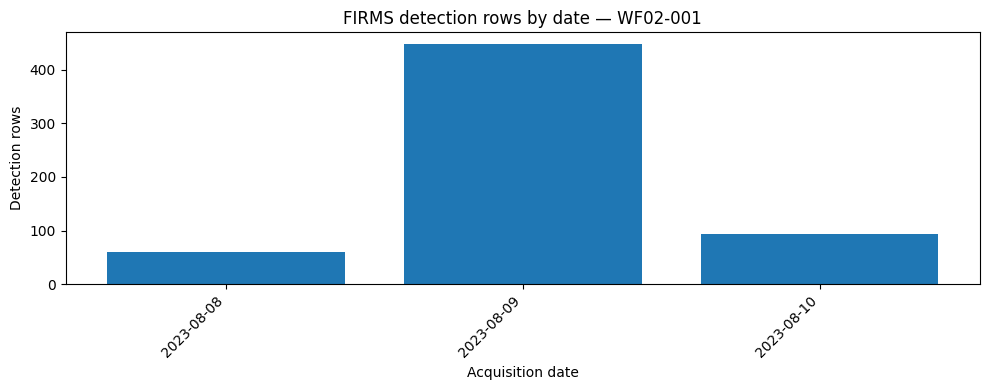

Saved: /content/wildfire_monitoring/results/WF02_timeline_WF02-001.png


In [15]:

# ============================================================
# WF02 — Cell 13: Plot historical detection timeline
# ============================================================

import matplotlib.pyplot as plt

if daily_counts.empty:
    raise ValueError("Daily detection table is empty; there is nothing to plot.")

for event_id, group in daily_counts.groupby("event_id"):
    group = group.sort_values("acq_date")

    plt.figure(figsize=(10, 4))
    plt.bar(group["acq_date"].dt.strftime("%Y-%m-%d"),
            group["detection_count"])
    plt.title(f"FIRMS detection rows by date — {event_id}")
    plt.xlabel("Acquisition date")
    plt.ylabel("Detection rows")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    safe_id = "".join(
        char if char.isalnum() or char in "-_" else "_"
        for char in str(event_id)
    )
    output_path = RESULTS_DIR / f"WF02_timeline_{safe_id}.png"
    plt.savefig(output_path, dpi=160)
    plt.show()
    plt.close()

    print("Saved:", output_path)

In [16]:

# ============================================================
# WF02 — Cell 14: Generate preliminary summary and limitations
# ============================================================

from datetime import datetime, timezone

summary_path = RESULTS_DIR / "WF02_summary.md"

lines = [
    "# WF02 — FIRMS Detection Reliability: Preliminary Summary",
    "",
    f"Generated UTC: {datetime.now(timezone.utc).isoformat()}",
    "",
    "## Objective",
    "",
    "Inspect NASA FIRMS historical active-fire detections around "
    "independently documented fire events.",
    "",
    "## Event reference",
    "",
]

for _, event in events_df.iterrows():
    lines.extend([
        f"### {event['event_name']}",
        f"- Event dates: {event['event_start_date']} to {event['event_end_date']}",
        f"- Reference: {event['reference_source_name']}",
        f"- Source URL: {event['reference_source_url']}",
        "",
    ])

lines.extend([
    "## Retrieved data",
    "",
    f"- Valid detection rows retained: {len(firms_df)}",
    f"- Number of events with returned observations: "
    f"{firms_df['event_id'].nunique()}",
    f"- Acquisition dates represented: "
    f"{firms_df['acq_date'].min().date()} to "
    f"{firms_df['acq_date'].max().date()}",
    "",
    "## Interpretation limits",
    "",
    "- A FIRMS record is a satellite active-fire/thermal-anomaly detection, "
    "not definitive proof of a wildfire.",
    "- No returned detection in the selected search window does not, by itself, "
    "prove a missed detection. Sensor coverage, cloud/smoke conditions, "
    "overpass timing, product availability, and the chosen search area matter.",
    "- A detection near a documented event is not automatically a true positive; "
    "the spatial and temporal match must be checked.",
    "- One event is a pilot case study, not enough to generalize reliability "
    "across regions, seasons, or satellite products.",
    "- This analysis is descriptive; it does not yet calculate validated "
    "false-positive or missed-detection rates.",
    "",
    "## Output files",
    "",
    "- `WF02_query_windows.csv`",
    "- `WF02_request_log.csv`",
    "- `WF02_historical_firms_detections.csv`",
    "- `WF02_daily_detection_counts.csv`",
    "- `WF02_event_detection_summary.csv`",
    "- Event timeline PNG files",
    "",
])

summary_path.write_text("\n".join(lines), encoding="utf-8")

print("Saved preliminary summary:", summary_path)
print(summary_path.read_text(encoding="utf-8"))

Saved preliminary summary: /content/wildfire_monitoring/results/WF02_summary.md
# WF02 — FIRMS Detection Reliability: Preliminary Summary

Generated UTC: 2026-10-10T14:43:55.980476+00:00

## Objective

Inspect NASA FIRMS historical active-fire detections around independently documented fire events.

## Event reference

### Lahaina Wildfires
- Event dates: 2023-08-08 00:00:00 to 2023-08-09 00:00:00
- Reference: NOAA IncidentNews
- Source URL: https://incidentnews.noaa.gov/incident/10650

## Retrieved data

- Valid detection rows retained: 600
- Number of events with returned observations: 1
- Acquisition dates represented: 2023-08-08 to 2023-08-10

## Interpretation limits

- A FIRMS record is a satellite active-fire/thermal-anomaly detection, not definitive proof of a wildfire.
- No returned detection in the selected search window does not, by itself, prove a missed detection. Sensor coverage, cloud/smoke conditions, overpass timing, product availability, and the chosen search area mat

In [17]:

# ============================================================
# WF02 — Cell 15: Verify expected output files
# ============================================================

expected_files = [
    RESULTS_DIR / "WF02_query_windows.csv",
    RESULTS_DIR / "WF02_request_log.csv",
    DATA_DIR / "WF02_historical_firms_detections.csv",
    RESULTS_DIR / "WF02_daily_detection_counts.csv",
    RESULTS_DIR / "WF02_event_detection_summary.csv",
    RESULTS_DIR / "WF02_summary.md",
]

verification_rows = []

for path in expected_files:
    exists = path.is_file()
    size_bytes = path.stat().st_size if exists else 0

    verification_rows.append({
        "file": path.name,
        "exists": exists,
        "size_bytes": size_bytes,
        "non_empty": exists and size_bytes > 0,
    })

verification_df = pd.DataFrame(verification_rows)
verification_path = RESULTS_DIR / "WF02_output_verification.csv"
verification_df.to_csv(verification_path, index=False)

display(verification_df)
print("Verification report:", verification_path)

if verification_df["non_empty"].all():
    print("WF02 outputs verified. Review the data and limitations before interpreting results.")
else:
    print(
        "Some outputs are missing or empty. Review the request log and "
        "correct the cause before claiming the experiment is complete."
    )

,file,exists,size_bytes,non_empty
0,WF02_query_windows.csv,True,149,True
1,WF02_request_log.csv,True,348,True
2,WF02_historical_firms_detections.csv,True,76295,True
3,WF02_daily_detection_counts.csv,True,169,True
4,WF02_event_detection_summary.csv,True,154,True
5,WF02_summary.md,True,1492,True


Verification report: /content/wildfire_monitoring/results/WF02_output_verification.csv
WF02 outputs verified. Review the data and limitations before interpreting results.


In [18]:

# ============================================================
# WF02 — Cell 16: Quality checks and event coverage
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

BASE_DIR = Path("/content/wildfire_monitoring")
DATA_DIR = BASE_DIR / "data"
RESULTS_DIR = BASE_DIR / "results"
EVENTS_CSV_PATH = DATA_DIR / "event_references" / "historical_fire_events.csv"

# Load the saved files so this cell can also be rerun independently.
events_check = pd.read_csv(EVENTS_CSV_PATH)
requests_check = pd.read_csv(RESULTS_DIR / "WF02_request_log.csv")

# Restore acquisition dates and coordinate types.
detections_check = pd.read_csv(
    DATA_DIR / "WF02_historical_firms_detections.csv"
)

detections_check["acq_date"] = pd.to_datetime(
    detections_check["acq_date"], errors="coerce"
)
detections_check["latitude"] = pd.to_numeric(
    detections_check["latitude"], errors="coerce"
)
detections_check["longitude"] = pd.to_numeric(
    detections_check["longitude"], errors="coerce"
)

# Summarize API request status.
print("Request status counts:")
display(
    requests_check["status"]
    .value_counts(dropna=False)
    .rename_axis("status")
    .reset_index(name="request_count")
)

# Check which events have returned detection rows.
if "event_id" not in detections_check.columns:
    raise ValueError("The downloaded detection file has no event_id column.")

detection_counts = (
    detections_check.groupby("event_id")
    .size()
    .rename("returned_detection_rows")
    .reset_index()
)

coverage = events_check[
    ["event_id", "event_name", "event_start_date", "event_end_date"]
].merge(detection_counts, on="event_id", how="left")

coverage["returned_detection_rows"] = (
    coverage["returned_detection_rows"].fillna(0).astype(int)
)

coverage_path = RESULTS_DIR / "WF02_event_coverage.csv"
coverage.to_csv(coverage_path, index=False)

print("\nEvent coverage:")
display(coverage)
print("Saved:", coverage_path)

# Save the cleaned frame back into the variables used by later cells.
firms_df = detections_check.copy()
events_df = events_check.copy()

print("\nQuality check complete.")
print("Note: zero returned rows do not prove a satellite missed the event.")

Request status counts:


,status,request_count
0,success,6



Event coverage:


,event_id,event_name,event_start_date,event_end_date,returned_detection_rows
0,WF02-001,Lahaina Wildfires,2023-08-08,2023-08-09,600


Saved: /content/wildfire_monitoring/results/WF02_event_coverage.csv

Quality check complete.
Note: zero returned rows do not prove a satellite missed the event.


In [19]:

# ============================================================
# WF02 — Cell 17: Event-level spatial and temporal comparison
# ============================================================

import numpy as np
import pandas as pd

# Analysis choices: document these in the report.
# These are exploratory matching thresholds, not official fire boundaries.
MATCH_RADIUS_KM = 30
MATCH_DAYS_BEFORE = 2
MATCH_DAYS_AFTER = 2

def haversine_km(lat1, lon1, lat2, lon2):
    """
    Calculate approximate great-circle distance in kilometres.
    Coordinates may be supplied as NumPy arrays or pandas Series.
    """
    earth_radius_km = 6371.0

    lat1 = np.radians(np.asarray(lat1, dtype=float))
    lon1 = np.radians(np.asarray(lon1, dtype=float))
    lat2 = np.radians(float(lat2))
    lon2 = np.radians(float(lon2))

    delta_lat = lat2 - lat1
    delta_lon = lon2 - lon1

    a = (
        np.sin(delta_lat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2)
        * np.sin(delta_lon / 2) ** 2
    )

    # Numerical safety: keep values within the valid arcsine domain.
    a = np.clip(a, 0, 1)
    return 2 * earth_radius_km * np.arcsin(np.sqrt(a))


# Normalize date and coordinate fields.
firms_df["acq_date"] = pd.to_datetime(
    firms_df["acq_date"], errors="coerce"
)
firms_df["latitude"] = pd.to_numeric(
    firms_df["latitude"], errors="coerce"
)
firms_df["longitude"] = pd.to_numeric(
    firms_df["longitude"], errors="coerce"
)

event_matches = []

for _, event in events_df.iterrows():
    start_date = pd.to_datetime(event["event_start_date"])
    end_date = pd.to_datetime(event["event_end_date"])

    # Limit observations to the same event ID.
    event_detections = firms_df[
        firms_df["event_id"].astype(str) == str(event["event_id"])
    ].copy()

    # Compute distance from each satellite detection to the
    # approximate event reference coordinate.
    if not event_detections.empty:
        event_detections["distance_from_reference_km"] = haversine_km(
            event_detections["latitude"],
            event_detections["longitude"],
            event["latitude"],
            event["longitude"],
        )

        # Check dates independently of the distance threshold.
        event_detections["within_event_date_window"] = (
            event_detections["acq_date"]
            >= start_date - pd.Timedelta(days=MATCH_DAYS_BEFORE)
        ) & (
            event_detections["acq_date"]
            <= end_date + pd.Timedelta(days=MATCH_DAYS_AFTER)
        )

        # Candidate match = close enough AND within the date window.
        event_detections["candidate_spatiotemporal_match"] = (
            event_detections["distance_from_reference_km"]
            <= MATCH_RADIUS_KM
        ) & event_detections["within_event_date_window"]

        candidate = event_detections[
            event_detections["candidate_spatiotemporal_match"]
        ]

        closest_distance = event_detections[
            "distance_from_reference_km"
        ].min()

        candidate_dates = candidate["acq_date"].nunique()
        candidate_rows = len(candidate)
    else:
        closest_distance = np.nan
        candidate_dates = 0
        candidate_rows = 0

    event_matches.append({
        "event_id": event["event_id"],
        "event_name": event["event_name"],
        "reference_start_date": start_date.date().isoformat(),
        "reference_end_date": end_date.date().isoformat(),
        "all_returned_detection_rows": len(event_detections),
        "closest_detection_distance_km": closest_distance,
        "candidate_match_rows": candidate_rows,
        "candidate_match_dates": candidate_dates,
        "match_radius_km": MATCH_RADIUS_KM,
        "date_buffer_days": MATCH_DAYS_BEFORE,
        "interpretation": (
            "Candidate association only; independent confirmation required."
        ),
    })

event_match_df = pd.DataFrame(event_matches)
event_match_path = RESULTS_DIR / "WF02_event_spatiotemporal_matches.csv"
event_match_df.to_csv(event_match_path, index=False)

display(event_match_df)
print("Saved:", event_match_path)

,event_id,event_name,reference_start_date,reference_end_date,all_returned_detection_rows,closest_detection_distance_km,candidate_match_rows,candidate_match_dates,match_radius_km,date_buffer_days,interpretation
0,WF02-001,Lahaina Wildfires,2023-08-08,2023-08-09,600,0.103417,267,2,30,2,Candidate association only; independent confir...


Saved: /content/wildfire_monitoring/results/WF02_event_spatiotemporal_matches.csv


In [20]:

# ============================================================
# WF02 — Cell 18: Inspect detection confidence and FRP
# ============================================================

import pandas as pd
import numpy as np

# Work on a copy to avoid changing the raw downloaded dataset.
attribute_df = firms_df.copy()

# Store which confidence values actually appear in the data.
if "confidence" in attribute_df.columns:
    confidence_counts = (
        attribute_df["confidence"]
        .fillna("missing")
        .astype(str)
        .value_counts(dropna=False)
        .rename_axis("confidence_value")
        .reset_index(name="detection_rows")
    )

    confidence_path = RESULTS_DIR / "WF02_confidence_value_counts.csv"
    confidence_counts.to_csv(confidence_path, index=False)

    print("Confidence values:")
    display(confidence_counts)
    print("Saved:", confidence_path)
else:
    print("No confidence column exists in this product's response.")

# Summarize numerical attributes only when present and convertible.
numeric_candidates = [
    "bright_ti4",
    "bright_ti5",
    "brightness",
    "frp",
    "scan",
    "track",
]

numeric_summary_rows = []

for column in numeric_candidates:
    if column not in attribute_df.columns:
        continue

    values = pd.to_numeric(attribute_df[column], errors="coerce")
    valid_values = values.dropna()

    numeric_summary_rows.append({
        "field": column,
        "valid_numeric_rows": len(valid_values),
        "missing_or_non_numeric_rows": int(values.isna().sum()),
        "minimum": valid_values.min() if len(valid_values) else np.nan,
        "median": valid_values.median() if len(valid_values) else np.nan,
        "mean": valid_values.mean() if len(valid_values) else np.nan,
        "maximum": valid_values.max() if len(valid_values) else np.nan,
    })

numeric_summary_df = pd.DataFrame(numeric_summary_rows)
numeric_summary_path = RESULTS_DIR / "WF02_detection_attribute_summary.csv"
numeric_summary_df.to_csv(numeric_summary_path, index=False)

display(numeric_summary_df)
print("Saved:", numeric_summary_path)

# Important:
# FRP and brightness are satellite-observed attributes, not ground truth.
# Do not classify a detection as true/false based only on these fields.

Confidence values:


,confidence_value,detection_rows
0,n,442
1,l,52
2,h,45
3,100,27
4,96,3
5,86,3
6,52,2
7,78,2
8,97,1
9,88,1


Saved: /content/wildfire_monitoring/results/WF02_confidence_value_counts.csv


,field,valid_numeric_rows,missing_or_non_numeric_rows,minimum,median,mean,maximum
0,bright_ti4,539,61,299.34,336.96,334.305306,367.00
1,bright_ti5,539,61,286.57,296.71,299.991874,342.62
2,brightness,61,539,306.60,327.20,334.567213,410.60
3,frp,600,0,0.28,7.36,22.250283,1031.50
4,scan,600,0,0.36,0.42,0.607783,4.20
5,track,600,0,0.37,0.58,0.586450,1.90


Saved: /content/wildfire_monitoring/results/WF02_detection_attribute_summary.csv


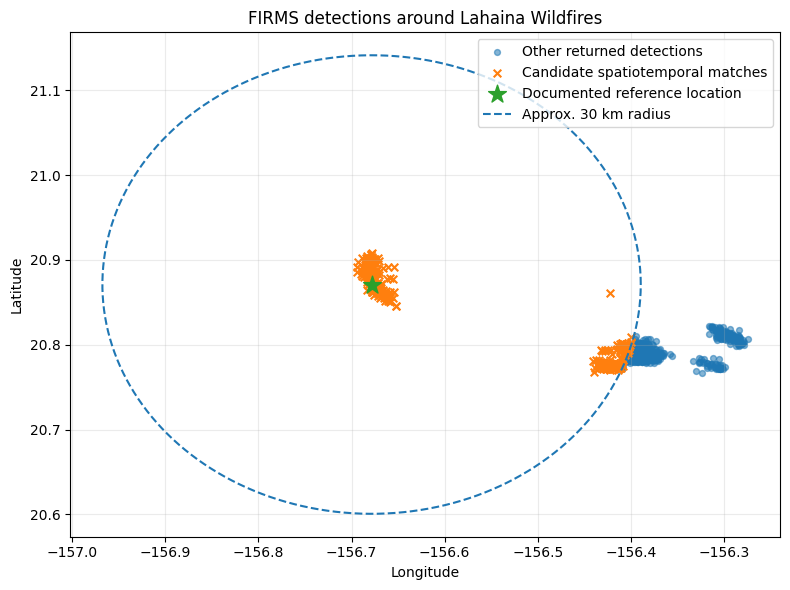

Saved: /content/wildfire_monitoring/results/WF02_spatial_matches_WF02-001.png
Reminder: these maps show proximity to a reference point, not verified true positives or false alarms.


In [21]:

# ============================================================
# WF02 — Cell 19: Plot detections and candidate matches
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Recalculate candidate matches for plotting using Cell 17's thresholds.
plot_df = firms_df.copy()
plot_df["acq_date"] = pd.to_datetime(plot_df["acq_date"], errors="coerce")

plot_rows = []

for _, event in events_df.iterrows():
    subset = plot_df[
        plot_df["event_id"].astype(str) == str(event["event_id"])
    ].copy()

    if subset.empty:
        print(f"No detections to plot for {event['event_name']}.")
        continue

    subset["distance_km"] = haversine_km(
        subset["latitude"],
        subset["longitude"],
        event["latitude"],
        event["longitude"],
    )

    start_date = pd.to_datetime(event["event_start_date"])
    end_date = pd.to_datetime(event["event_end_date"])

    subset["candidate_match"] = (
        subset["distance_km"].le(MATCH_RADIUS_KM)
        & subset["acq_date"].ge(
            start_date - pd.Timedelta(days=MATCH_DAYS_BEFORE)
        )
        & subset["acq_date"].le(
            end_date + pd.Timedelta(days=MATCH_DAYS_AFTER)
        )
    )

    # Plot a local window so the event and nearby detections are visible.
    fig, ax = plt.subplots(figsize=(8, 6))

    other = subset[~subset["candidate_match"]]
    candidates = subset[subset["candidate_match"]]

    if not other.empty:
        ax.scatter(
            other["longitude"],
            other["latitude"],
            s=18,
            alpha=0.55,
            label="Other returned detections",
        )

    if not candidates.empty:
        ax.scatter(
            candidates["longitude"],
            candidates["latitude"],
            s=30,
            marker="x",
            label="Candidate spatiotemporal matches",
        )

    # The documented location is approximate, not a fire perimeter.
    ax.scatter(
        [event["longitude"]],
        [event["latitude"]],
        marker="*",
        s=180,
        label="Documented reference location",
    )

    # A 30 km radius is shown approximately in latitude degrees.
    # Longitude scale changes with latitude, so this is only a visual guide.
    radius_lat = MATCH_RADIUS_KM / 111.0
    angles = np.linspace(0, 2 * np.pi, 200)
    circle_lat = event["latitude"] + radius_lat * np.sin(angles)
    circle_lon = event["longitude"] + (
        radius_lat * np.cos(angles)
        / max(np.cos(np.radians(event["latitude"])), 0.01)
    )
    ax.plot(circle_lon, circle_lat, linestyle="--", label="Approx. 30 km radius")

    ax.set_title(f"FIRMS detections around {event['event_name']}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend()
    ax.grid(True, alpha=0.25)
    fig.tight_layout()

    safe_id = "".join(
        c if c.isalnum() or c in "-_" else "_"
        for c in str(event["event_id"])
    )
    figure_path = RESULTS_DIR / f"WF02_spatial_matches_{safe_id}.png"
    fig.savefig(figure_path, dpi=160)
    plt.show()
    plt.close(fig)

    print("Saved:", figure_path)

print(
    "Reminder: these maps show proximity to a reference point, "
    "not verified true positives or false alarms."
)

In [22]:

# ============================================================
# WF02 — Cell 20: Write the event-level evaluation report
# ============================================================

from datetime import datetime, timezone
from pathlib import Path

report_path = RESULTS_DIR / "WF02_event_evaluation.md"

lines = [
    "# WF02 — FIRMS Detection Reliability: Event-Level Evaluation",
    "",
    f"Generated (UTC): {datetime.now(timezone.utc).isoformat()}",
    "",
    "## Objective",
    "",
    "Examine whether NASA FIRMS active-fire detections are spatially and "
    "temporally associated with independently documented fire events.",
    "",
    "## Matching method",
    "",
    f"- Approximate matching radius: {MATCH_RADIUS_KM} km.",
    f"- Date buffer before event: {MATCH_DAYS_BEFORE} days.",
    f"- Date buffer after event: {MATCH_DAYS_AFTER} days.",
    "- The reference coordinate is approximate and does not represent "
    "the official fire perimeter.",
    "- A candidate match is not treated as a confirmed true positive.",
    "",
    "## Event-level results",
    "",
    event_match_df.to_markdown(index=False),
    "",
    "## Interpretation",
    "",
    "Candidate matches indicate that FIRMS returned observations near "
    "the documented event in the selected time window. They do not, "
    "on their own, establish detection reliability.",
    "",
    "An independent fire perimeter, incident report, or other suitable "
    "reference dataset is needed to determine which observations correspond "
    "to the event and to assess omissions or false alarms.",
    "",
    "## Limitations",
    "",
    "- This is a preliminary case study; one event is not enough to "
    "generalize to other locations or seasons.",
    "- An approximate event point and a circular buffer cannot reproduce "
    "the actual fire perimeter.",
    "- Satellite overpass timing, cloud or smoke, spatial resolution, "
    "and sensor/product differences can affect detections.",
    "- A detection outside the selected buffer is not automatically a "
    "false alarm; it may correspond to another fire.",
    "- A day with no returned records is not automatically a missed detection.",
    "- No validated precision, recall, or false-alarm rate is reported "
    "because independently labeled detection-level ground truth has not "
    "yet been established.",
    "",
    "## Files generated",
    "",
    "- `WF02_event_coverage.csv`",
    "- `WF02_event_spatiotemporal_matches.csv`",
    "- `WF02_confidence_value_counts.csv` (when confidence is available)",
    "- `WF02_detection_attribute_summary.csv`",
    "- `WF02_spatial_matches_<event_id>.png`",
    "- `WF02_event_evaluation.md`",
    "",
]

report_path.write_text("\n".join(lines), encoding="utf-8")

print("Saved:", report_path)
print(report_path.read_text(encoding="utf-8"))

Saved: /content/wildfire_monitoring/results/WF02_event_evaluation.md
# WF02 — FIRMS Detection Reliability: Event-Level Evaluation

Generated (UTC): 2026-10-10T14:47:08.001056+00:00

## Objective

Examine whether NASA FIRMS active-fire detections are spatially and temporally associated with independently documented fire events.

## Matching method

- Approximate matching radius: 30 km.
- Date buffer before event: 2 days.
- Date buffer after event: 2 days.
- The reference coordinate is approximate and does not represent the official fire perimeter.
- A candidate match is not treated as a confirmed true positive.

## Event-level results

| event_id   | event_name        | reference_start_date   | reference_end_date   |   all_returned_detection_rows |   closest_detection_distance_km |   candidate_match_rows |   candidate_match_dates |   match_radius_km |   date_buffer_days | interpretation                                                 |
|:-----------|:------------------|:----------------

In [23]:

# ============================================================
# WF02 — Cell 21: Final output verification
# ============================================================

expected_outputs = [
    RESULTS_DIR / "WF02_query_windows.csv",
    RESULTS_DIR / "WF02_request_log.csv",
    RESULTS_DIR / "WF02_event_coverage.csv",
    RESULTS_DIR / "WF02_event_spatiotemporal_matches.csv",
    RESULTS_DIR / "WF02_detection_attribute_summary.csv",
    RESULTS_DIR / "WF02_event_evaluation.md",
]

# Some outputs are conditional because not every FIRMS product contains
# every field. Check the confidence file only if Cell 18 created it.
conditional_outputs = [
    RESULTS_DIR / "WF02_confidence_value_counts.csv",
]

expected_outputs.extend(
    path for path in conditional_outputs if path.exists()
)

# Include the historical detections file only if it exists.
historical_path = DATA_DIR / "WF02_historical_firms_detections.csv"
if historical_path.exists():
    expected_outputs.append(historical_path)

verification_rows = []

for path in expected_outputs:
    exists = path.is_file()
    size = path.stat().st_size if exists else 0

    verification_rows.append({
        "file": path.name,
        "exists": exists,
        "size_bytes": size,
        "non_empty": exists and size > 0,
    })

verification_df = pd.DataFrame(verification_rows)
verification_path = RESULTS_DIR / "WF02_final_verification.csv"
verification_df.to_csv(verification_path, index=False)

display(verification_df)
print("Saved verification table:", verification_path)

if verification_df["non_empty"].all():
    print("All checked WF02 outputs exist and are non-empty.")
else:
    print("Some outputs are missing or empty. Investigate before proceeding.")

print(
    "\nScientific status: preliminary event-level comparison. "
    "Do not claim verified detection accuracy without independent labels."
)

,file,exists,size_bytes,non_empty
0,WF02_query_windows.csv,True,149,True
1,WF02_request_log.csv,True,348,True
2,WF02_event_coverage.csv,True,129,True
3,WF02_event_spatiotemporal_matches.csv,True,356,True
4,WF02_detection_attribute_summary.csv,True,397,True
5,WF02_event_evaluation.md,True,2828,True
6,WF02_confidence_value_counts.csv,True,195,True
7,WF02_historical_firms_detections.csv,True,76295,True


Saved verification table: /content/wildfire_monitoring/results/WF02_final_verification.csv
All checked WF02 outputs exist and are non-empty.

Scientific status: preliminary event-level comparison. Do not claim verified detection accuracy without independent labels.


In [24]:

# ============================================================
# WF02 — Cell 22: Final Research Conclusion
# ============================================================

from pathlib import Path
from datetime import datetime, timezone
import pandas as pd
import numpy as np

# Define output paths.
BASE_DIR = Path("/content/wildfire_monitoring")
DATA_DIR = BASE_DIR / "data"
RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Load the event-level comparison generated in Cell 17.
MATCH_PATH = RESULTS_DIR / "WF02_event_spatiotemporal_matches.csv"
REQUEST_PATH = RESULTS_DIR / "WF02_request_log.csv"

if not MATCH_PATH.exists():
    raise FileNotFoundError(
        "Run Cell 17 first. Event-match results were not found."
    )

match_df = pd.read_csv(MATCH_PATH)

# Read request logs when available.
if REQUEST_PATH.exists():
    request_df = pd.read_csv(REQUEST_PATH)
else:
    request_df = pd.DataFrame()

# Calculate descriptive findings from the actual results.
number_of_events = len(match_df)

total_detection_rows = (
    pd.to_numeric(
        match_df["all_returned_detection_rows"],
        errors="coerce"
    ).fillna(0).sum()
)

total_candidate_rows = (
    pd.to_numeric(
        match_df["candidate_match_rows"],
        errors="coerce"
    ).fillna(0).sum()
)

events_with_candidates = (
    pd.to_numeric(
        match_df["candidate_match_rows"],
        errors="coerce"
    ).fillna(0) > 0
).sum()

# Count request failures, if a status column exists.
failed_requests = 0
successful_requests = 0

if not request_df.empty and "status" in request_df.columns:
    status = request_df["status"].astype(str).str.lower()
    failed_requests = int((status == "failed").sum())
    successful_requests = int((status == "success").sum())

# Build a conclusion that accurately describes the experiment.
conclusion_lines = [
    "# WF02 — Final Conclusion",
    "",
    f"Generated (UTC): {datetime.now(timezone.utc).isoformat()}",
    "",
    "## Experiment objective",
    "",
    "This experiment examined NASA FIRMS historical active-fire observations "
    "around independently documented fire events using predefined spatial "
    "and temporal search windows.",
    "",
    "## Observed results",
    "",
    f"- Events examined: {number_of_events}",
    f"- Returned detection rows across event queries: {int(total_detection_rows)}",
    f"- Candidate spatiotemporal match rows: {int(total_candidate_rows)}",
    f"- Events with at least one candidate match: {int(events_with_candidates)}",
    f"- Successful API requests recorded: {successful_requests}",
    f"- Failed API requests recorded: {failed_requests}",
    "",
    "## Conclusion",
    "",
]

if total_detection_rows == 0:
    conclusion_lines.extend([
        "No historical FIRMS detection rows were available in the saved "
        "event-level results. Therefore, this run cannot determine whether "
        "FIRMS detected the documented events. API availability, request "
        "errors, product coverage, date windows, and coordinates must be "
        "checked before drawing any conclusion.",
    ])
elif total_candidate_rows == 0:
    conclusion_lines.extend([
        "FIRMS returned observations for the selected event queries, but "
        "none met the predefined spatial and temporal matching criteria. "
        "This does not prove that FIRMS missed the fires: the reference "
        "coordinates, selected buffer, sensor overpass timing, product "
        "coverage, and returned detections require further investigation.",
    ])
else:
    conclusion_lines.extend([
        "Some returned FIRMS observations met the predefined spatial and "
        "temporal matching criteria for the documented events. These are "
        "candidate associations, not independently confirmed true positives. "
        "The result supports further event-level investigation but does not "
        "establish FIRMS detection accuracy or reliability.",
    ])

conclusion_lines.extend([
    "",
    "## Research limitations",
    "",
    "1. The analysis is a preliminary case study and may cover too few events "
    "to generalize across locations, seasons, or satellite products.",
    "2. A reference coordinate and a circular search buffer do not represent "
    "the actual fire perimeter.",
    "3. A nearby detection may correspond to a different fire or thermal "
    "anomaly.",
    "4. No returned detection does not automatically mean a missed fire.",
    "5. Independent event perimeters or verified detection-level labels are "
    "needed to calculate defensible precision, recall, and false-alarm rates.",
    "",
    "## Final research status",
    "",
    "**Status: Preliminary event-level comparison completed, subject to "
    "review of the saved request log and output files.**",
    "",
    "The experiment establishes a reproducible workflow for querying and "
    "examining FIRMS observations around documented events. It does not yet "
    "prove that FIRMS is reliable or unreliable.",
    "",
    "## Next step",
    "",
    "Proceed to WF03, the NBR/dNBR burned-area baseline, and investigate "
    "whether pre-fire and post-fire satellite imagery reveals burn-related "
    "spectral change. Keep active-fire detection and burned-area mapping "
    "as separate tasks.",
    "",
])

# Save the conclusion to disk.
conclusion_path = RESULTS_DIR / "WF02_conclusion.md"
conclusion_path.write_text(
    "\n".join(conclusion_lines),
    encoding="utf-8"
)

print("WF02 conclusion generated successfully.")
print("Saved to:", conclusion_path)
print()
print(conclusion_path.read_text(encoding="utf-8"))

WF02 conclusion generated successfully.
Saved to: /content/wildfire_monitoring/results/WF02_conclusion.md

# WF02 — Final Conclusion

Generated (UTC): 2026-10-10T14:53:28.897349+00:00

## Experiment objective

This experiment examined NASA FIRMS historical active-fire observations around independently documented fire events using predefined spatial and temporal search windows.

## Observed results

- Events examined: 1
- Returned detection rows across event queries: 600
- Candidate spatiotemporal match rows: 267
- Events with at least one candidate match: 1
- Successful API requests recorded: 6
- Failed API requests recorded: 0

## Conclusion

Some returned FIRMS observations met the predefined spatial and temporal matching criteria for the documented events. These are candidate associations, not independently confirmed true positives. The result supports further event-level investigation but does not establish FIRMS detection accuracy or reliability.

## Research limitations

1. The a